In [1]:
import results_deser as rd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Pixel-grafting

This notebook produces tables and graphs provided in Section 6 of the report.

## CIFAR10

In [2]:
# cifar10
accs = [rd.load_testaccs("results/r_cf10_rn18_graft")]
df_lin10_1 = pd.DataFrame(accs)
df_lin10_1


,0.875,0.75,0.625,0.5
0,85.11,83.47,80.11,78.76


In [3]:
# cifar10
accs = [rd.load_testaccs("results/r_cf10_rn18_graft_ss&mo"+str(i)) for i in range(4)]
df_lin10_2 = pd.DataFrame(accs)
df_lin10_2

,0.75,0.5
0,84.61,78.35
1,83.54,80.80
2,84.57,79.57
3,83.86,77.95


In [4]:
# cifar10
accs = [rd.load_testaccs("results/r_cf10_rn18_graft_ss&mo_fill"+str(i)) for i in range(2)]
df_lin10_3 = pd.DataFrame(accs)
df_lin10_3


,0.875,0.625
0,85.67,80.89
1,85.09,82.46


In [5]:
# flatten list of lists
flat = lambda l: [item for sublist in l for item in sublist]
# returns column values df[col] if col exists in df, otherwise empty list
get_col_array = lambda col, df: df[col].to_list() if col in df.columns else []
# returns a flat list of column values df[col] of all dfs in dfs list
get_allvalues = lambda col, dfs: pd.Series(flat([get_col_array(col, df) for df in dfs]))


In [6]:

DF_10 = [df_lin10_1, df_lin10_2, df_lin10_3]
df_lin10 = pd.DataFrame(columns=df_lin10_1.columns)
for c in ('0.5', '0.625', '0.75', '0.875'):
    df_lin10[c] = get_allvalues(c, DF_10)
df_lin10 = df_lin10.transpose()
df_lin10["mean"] = df_lin10.mean(axis=1)
df_lin10

,0,1,2,3,4,mean
0.875,85.11,85.67,85.09,NaN,NaN,85.290000
0.75,83.47,84.61,83.54,84.57,83.86,84.010000
0.625,80.11,80.89,82.46,NaN,NaN,81.153333
0.5,78.76,78.35,80.80,79.57,77.95,79.086000


In [7]:
print(df_lin10.to_latex())

\begin{tabular}{lrrrrrr}
\toprule
{} &      0 &      1 &      2 &      3 &      4 &       mean \\
\midrule
0.875 &  85.11 &  85.67 &  85.09 &    NaN &    NaN &  85.290000 \\
0.75  &  83.47 &  84.61 &  83.54 &  84.57 &  83.86 &  84.010000 \\
0.625 &  80.11 &  80.89 &  82.46 &    NaN &    NaN &  81.153333 \\
0.5   &  78.76 &  78.35 &  80.80 &  79.57 &  77.95 &  79.086000 \\
\bottomrule
\end{tabular}



#### Benchmark

In [8]:
85.17

85.17

In [9]:
df_mean10 = df_lin10.copy()["mean"]
df_mean10

0.875    85.290000
0.75     84.010000
0.625    81.153333
0.5      79.086000
Name: mean, dtype: float64

## CIFAR100

In [10]:
# cifar100
accs = [rd.load_testaccs("results/r_cf100_rn18_graft")]
df_lin100_1 = pd.DataFrame(accs)
df_lin100_1

,0.75,0.5
0,53.14,49.58


In [11]:
# cifar100
accs = [rd.load_testaccs("results/r_cf100_rn18_graft_ss&mo"+str(i)) for i in range(3)]
df_lin100_2 = pd.DataFrame(accs)
df_lin100_2

,0.875,0.75,0.625,0.5
0,56.21,54.03,50.68,49.03
1,56.66,52.58,49.94,49.14
2,55.04,52.40,50.57,50.09


In [12]:

DF_100 = [df_lin100_1, df_lin100_2]
df_lin100 = pd.DataFrame(columns=df_lin100_2.columns)
for c in ('0.5', '0.625', '0.75', '0.875'):
    df_lin100[c] = get_allvalues(c, DF_100)
df_lin100 = df_lin100.transpose()
df_lin100["mean"] = df_lin100.mean(axis=1)
df_lin100

,0,1,2,3,mean
0.875,56.21,56.66,55.04,NaN,55.970000
0.75,53.14,54.03,52.58,52.40,53.037500
0.625,50.68,49.94,50.57,NaN,50.396667
0.5,49.58,49.03,49.14,50.09,49.460000


In [13]:
print(df_lin100.to_latex())

\begin{tabular}{lrrrrr}
\toprule
{} &      0 &      1 &      2 &      3 &       mean \\
\midrule
0.875 &  56.21 &  56.66 &  55.04 &    NaN &  55.970000 \\
0.75  &  53.14 &  54.03 &  52.58 &  52.40 &  53.037500 \\
0.625 &  50.68 &  49.94 &  50.57 &    NaN &  50.396667 \\
0.5   &  49.58 &  49.03 &  49.14 &  50.09 &  49.460000 \\
\bottomrule
\end{tabular}



#### Benchmark

In [14]:
54.83

54.83

In [15]:
df_mean100 = df_lin100.copy()["mean"]
df_mean100

0.875    55.970000
0.75     53.037500
0.625    50.396667
0.5      49.460000
Name: mean, dtype: float64

## Graph

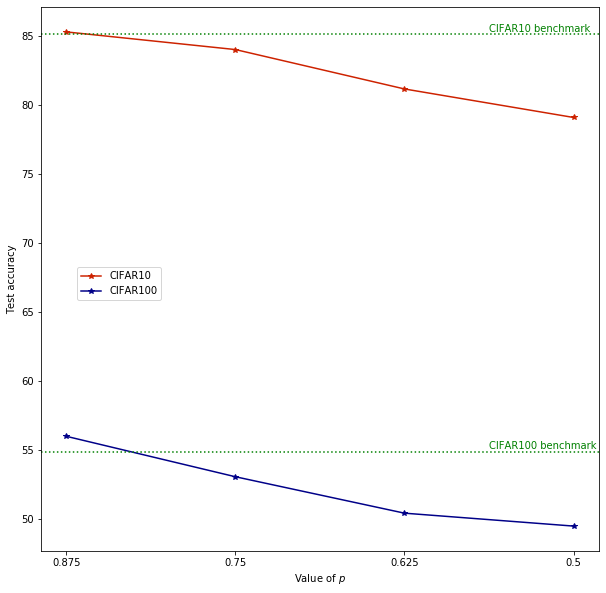

In [16]:
fig, ax = plt.subplots(figsize=(10, 10))
COLORS = ["#670000", "#cd2200", "#000088", "#0088ee"]

ax.plot(df_mean10, label="CIFAR10", color=COLORS[1], marker="*")
ax.plot(df_mean100, label="CIFAR100", color=COLORS[2], marker="*")

ax.axhline(y=85.17, linestyle="dotted", color="green")
ax.axhline(y=54.83, linestyle="dotted", color="green")
ax.text(x=2.5, y=85.27, s="CIFAR10 benchmark", color="green")
ax.text(x=2.5, y=55.03, s="CIFAR100 benchmark", color="green")
ax.set_xlabel("Value of $p$")
ax.set_ylabel("Test accuracy")
fig.legend(loc="lower left", bbox_to_anchor=(.1, .4))
fig.savefig("pixel_grafting.pdf")